# Clustering analysis

Here we will code several clustering methods like: k-Means, DBSCAN and Agglomerative clustering using python library sklearn.

Here we shall use synthetic dataset.

## Create the dataset

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

We will create dataset with 3 clusters with 0.5 standard deviation for each cluster. Number of sample 300 and we also choose three points as centroids (centre of clusters).

In [2]:
# Determine centroids
centres = [[0.5, 2], [-1,-1], [1.5, -1]]

# Create dataset
X, y = make_blobs(n_samples=300, centers=centres, cluster_std=0.5, random_state=100)

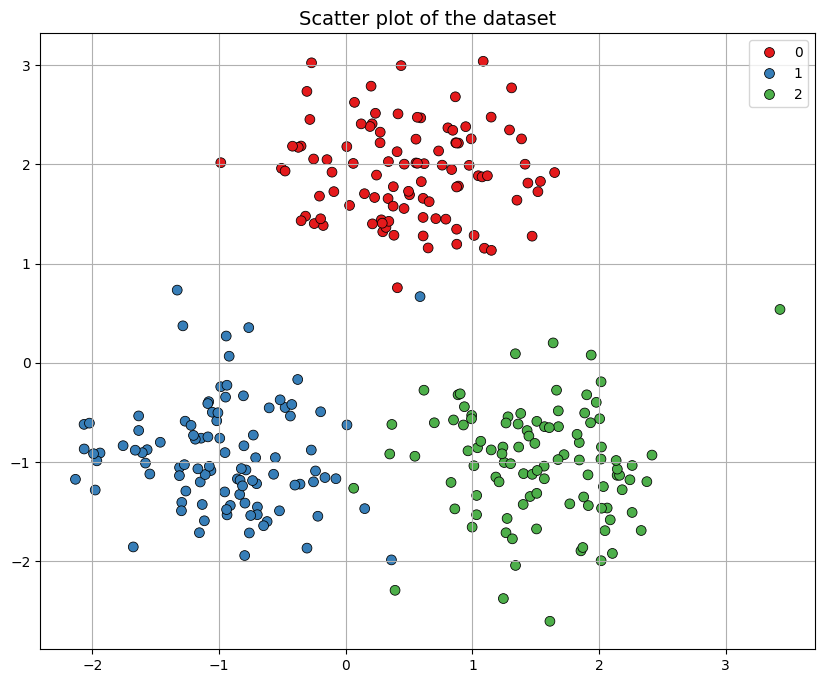

In [3]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='Set1', s=50, edgecolor='k')
plt.grid()
plt.legend()
plt.title("Scatter plot of the dataset", fontsize=14)
plt.show()

## Scale the dataset

In [4]:
X = StandardScaler().fit_transform(X)

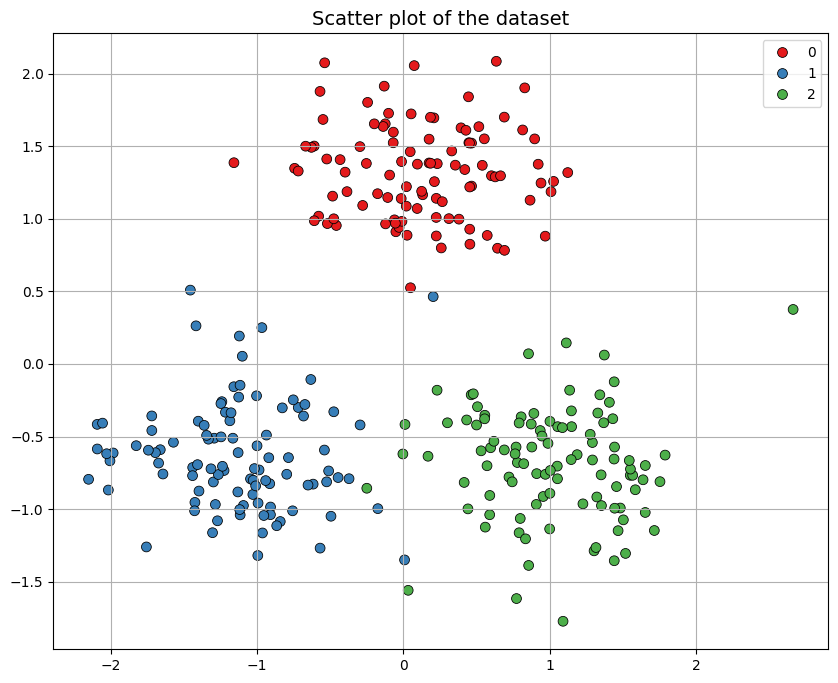

In [5]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='Set1', s=50, edgecolor='k')
plt.grid()
plt.title("Scatter plot of the dataset", fontsize=14)
plt.show()

## Apply k-means clustering

In [6]:
from sklearn.cluster import KMeans

### Finding optimal number of clusters in k-means (Elbow Method)

In [7]:
K = range(2, 10)

In [8]:
wcss_list = []

for k in K:
    model = KMeans(n_clusters=k)
    model.fit(X)
    wcss = model.inertia_   # .inertia_ attribute will give us the WCSS
    wcss_list.append(wcss)

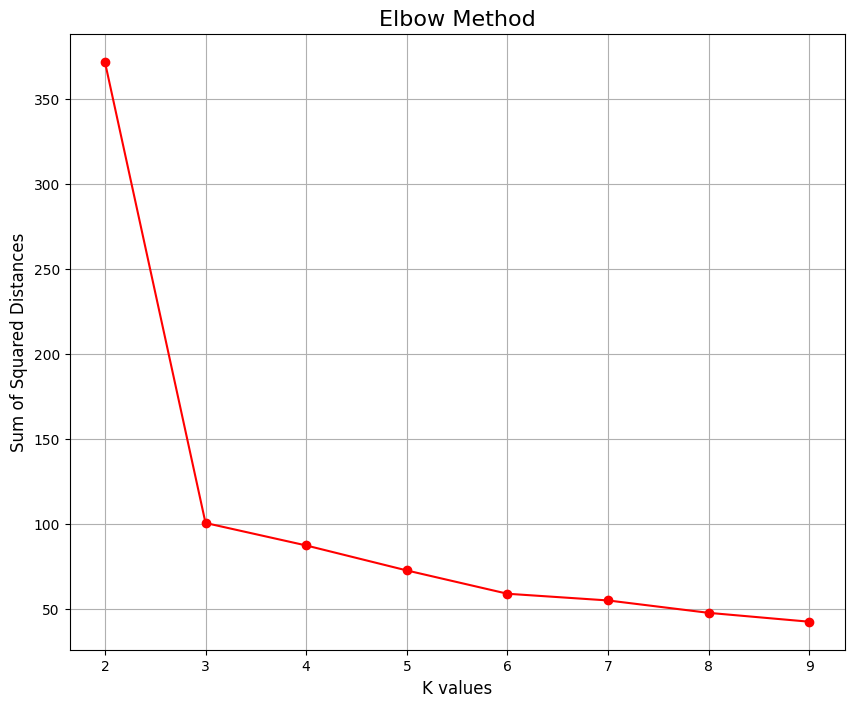

In [9]:
plt.figure(figsize=(10,8))
plt.plot(K, wcss_list, "ro-")
plt.xlabel("K values", fontsize=12)
plt.ylabel("Sum of Squared Distances",fontsize=12)
plt.title("Elbow Method",fontsize=16)
plt.grid()
plt.show()

So from our above exercise we can see that K=3 is the optimum number of cluster

### Fit the KMeans cluster with right value of k

In [10]:
model = KMeans(n_clusters=3)
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [11]:
labels = model.predict(X)

In [12]:
centroids = model.cluster_centers_

In [13]:
centroids

array([[-1.15287676, -0.64076956],
       [ 0.1219279 ,  1.31300138],
       [ 1.01820081, -0.69176953]])

In [14]:
centres

[[0.5, 2], [-1, -1], [1.5, -1]]

### Plot the output of kMeans clustering

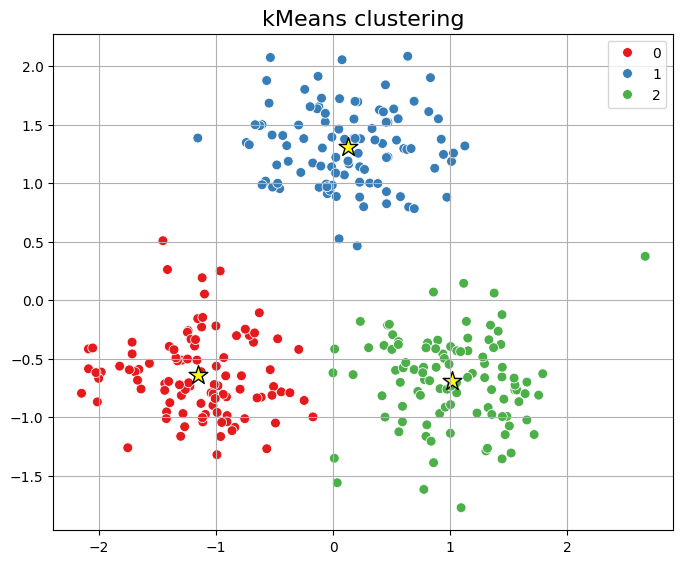

In [15]:
plt.figure(figsize=(8,8))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1', s=50)
plt.scatter(centroids[:,0], centroids[:,1], c='yellow', s=200, marker='*', edgecolor='k')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.grid()
plt.title("kMeans clustering", fontsize=16)
plt.show()

### Obtain the Sihouette Score of the clusters

In [16]:
from sklearn.metrics import silhouette_score

In [17]:
s = silhouette_score(X, labels, metric='euclidean')

In [18]:
print(f"The Silhouette score of KMeans clustering: {s:0.2f}",)

The Silhouette score of KMeans clustering: 0.65


## Apply DBSCAN clustering

In [19]:
from sklearn.cluster import DBSCAN

### Determine eps and minPts

In [20]:
eps = 0.40
minPts = 16

### Create the DBSCAN model and fit it

In [21]:
dbscan_model = DBSCAN(eps=eps, min_samples=minPts)

In [22]:
dbscan_model.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.4
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",16
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [23]:
labels_dbscan = dbscan_model.fit_predict(X)

### Plot the output of DBSCAN

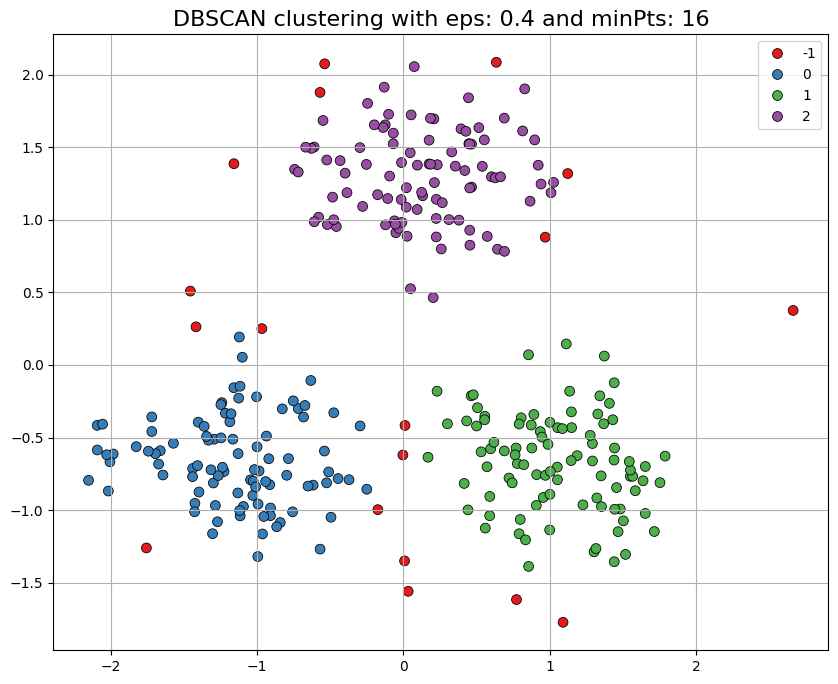

In [24]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels_dbscan, palette='Set1', s=50, edgecolor='k')
plt.title(f"DBSCAN clustering with eps: {eps} and minPts: {minPts}", fontsize=16)
plt.grid()
plt.show()

in this sklearn implementation of DBSCAN, label = -1 implies Noise points

### Obtain the silhouette score

In [25]:
print(f"The silhouette score: {silhouette_score(X, labels_dbscan, metric='euclidean'):0.2f}")

The silhouette score: 0.59


In [26]:
def noise_adjusted_silhouette_score(X, labels, metric='euclidean'):
    labels_wo_noise = labels[np.where(labels != -1)]
    X_wo_noise = X[np.where(labels != -1)]
    return silhouette_score(X_wo_noise, labels_wo_noise, metric=metric)

print(f"The silhouette score without noise points: {noise_adjusted_silhouette_score(X, labels_dbscan, metric='euclidean'):0.2f}")

The silhouette score without noise points: 0.68


### Methods for obtaining Optimal values of eps and MinPts based on Silhouette scores

In [27]:
range_of_eps = np.arange(0.1, 1.0, 0.1)
range_of_minPts = np.arange(5, 40, 5)

In [28]:
eps_minpts_comb = [(x,y) for x in range_of_eps for y in range_of_minPts]

In [29]:
eps_minpts_comb

[(np.float64(0.1), np.int64(5)),
 (np.float64(0.1), np.int64(10)),
 (np.float64(0.1), np.int64(15)),
 (np.float64(0.1), np.int64(20)),
 (np.float64(0.1), np.int64(25)),
 (np.float64(0.1), np.int64(30)),
 (np.float64(0.1), np.int64(35)),
 (np.float64(0.2), np.int64(5)),
 (np.float64(0.2), np.int64(10)),
 (np.float64(0.2), np.int64(15)),
 (np.float64(0.2), np.int64(20)),
 (np.float64(0.2), np.int64(25)),
 (np.float64(0.2), np.int64(30)),
 (np.float64(0.2), np.int64(35)),
 (np.float64(0.30000000000000004), np.int64(5)),
 (np.float64(0.30000000000000004), np.int64(10)),
 (np.float64(0.30000000000000004), np.int64(15)),
 (np.float64(0.30000000000000004), np.int64(20)),
 (np.float64(0.30000000000000004), np.int64(25)),
 (np.float64(0.30000000000000004), np.int64(30)),
 (np.float64(0.30000000000000004), np.int64(35)),
 (np.float64(0.4), np.int64(5)),
 (np.float64(0.4), np.int64(10)),
 (np.float64(0.4), np.int64(15)),
 (np.float64(0.4), np.int64(20)),
 (np.float64(0.4), np.int64(25)),
 (np.flo

In [30]:
def find_optimal_eps_minpts(values, noise_adjusted=True):
    best_score = -1
    for eps, minpts in values:
        dbscan_model = DBSCAN(eps=eps, min_samples=minpts)
        dbscan_model.fit(X)
        y_pred = dbscan_model.fit_predict(X)
        n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
        if n_clusters >= 2:
            if noise_adjusted:
                score = noise_adjusted_silhouette_score(X, labels=y_pred, metric='euclidean')
            else:
                score = silhouette_score(X, labels=y_pred, metric='euclidean')
            if score > best_score:
                best_score = score
                best_eps = eps
                best_minpts = minpts
    return best_eps, best_minpts, best_score

In [31]:
## Optimizing DBSCAN parameters with normal silhouette score
best_eps, best_minpts, best_score = find_optimal_eps_minpts(eps_minpts_comb, noise_adjusted=False)

print(f"The best eps: {best_eps}, best minPts: {best_minpts} with silhouette score: {best_score:0.2f}")

The best eps: 0.6, best minPts: 30 with silhouette score: 0.63


In [32]:
## Optimizing DBSCAN parameters with noise adjusted silhouette score
best_eps, best_minpts, best_score = find_optimal_eps_minpts(eps_minpts_comb, noise_adjusted=True)

print(f"The best eps: {best_eps:0.2f}, best minPts: {best_minpts} with noise adjusted silhouette score: {best_score:0.2f}")

The best eps: 0.30, best minPts: 25 with noise adjusted silhouette score: 0.83


### Optimal DBSCAN model

In [33]:
dbscan_model = DBSCAN(eps=0.6, min_samples=30)

In [34]:
y_pred = dbscan_model.fit_predict(X)

In [35]:
print(f"The silhouette score: {silhouette_score(X, y_pred, metric='euclidean'):0.2f}")
print(f"The noise adjusted silhouette score: {noise_adjusted_silhouette_score(X, y_pred, metric='euclidean'):0.2f}")

The silhouette score: 0.63
The noise adjusted silhouette score: 0.65


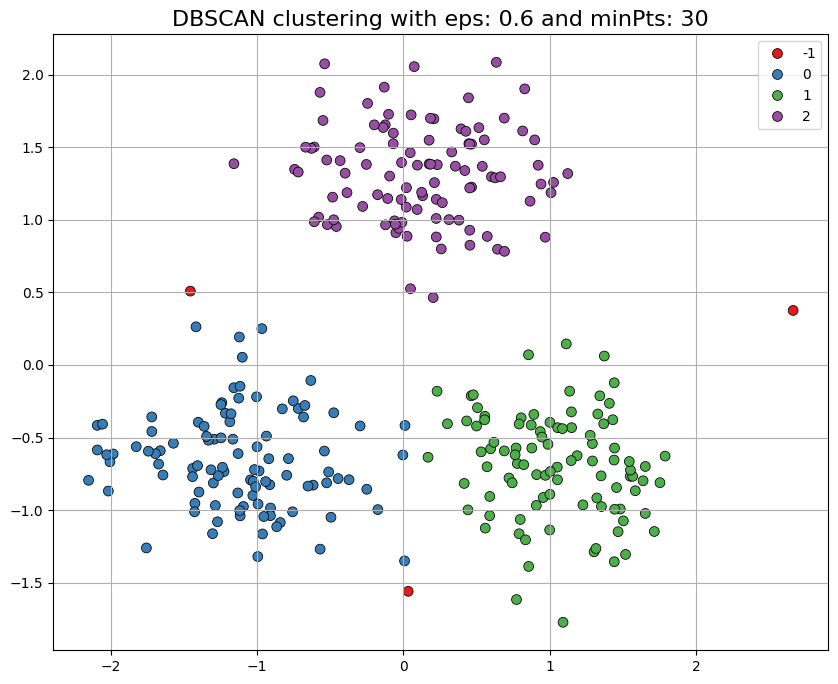

In [36]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred, palette='Set1', s=50, edgecolor='k')
plt.title(f"DBSCAN clustering with eps: 0.6 and minPts: 30", fontsize=16)
plt.grid()
plt.show()

## Agglomeartive Clustering

In [37]:
from sklearn.cluster import AgglomerativeClustering

### Create agglomearive clustering model and fit it

In [53]:
agg_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')

In [54]:
y_pred_agg = agg_cluster.fit_predict(X)

### Plot the output of Agglomerative Clustering

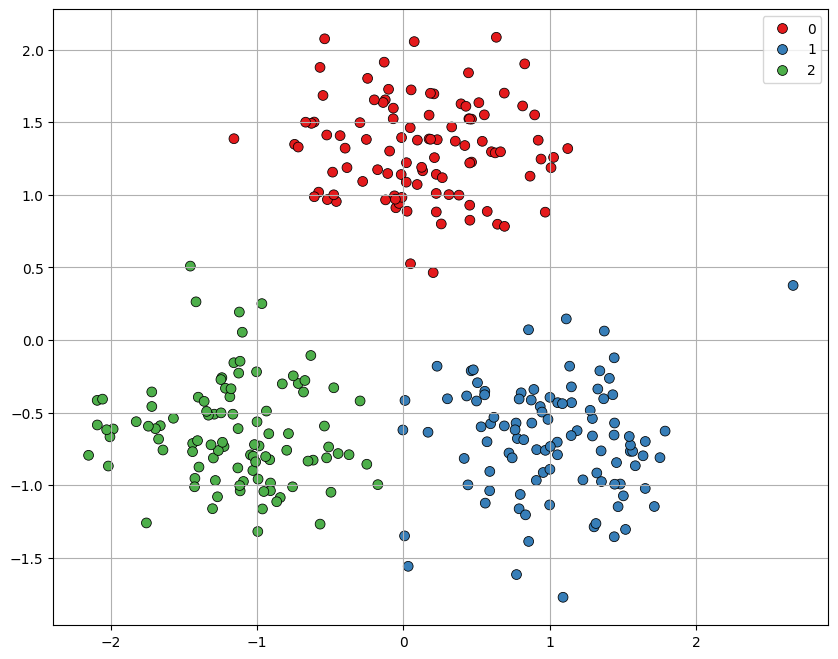

In [55]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_agg, palette='Set1', s=50, edgecolor='k')
plt.grid()
plt.show()

### Silhoutte score of Agglomerative Clustering

In [41]:
silhouette_score(X, y_pred_agg, metric='euclidean')

0.6472412342728544

### Visualizing the dendograms of Agglomerative Clustering

[scipy.cluster.hierarchy](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html)

In [42]:
import scipy.cluster.hierarchy as shc

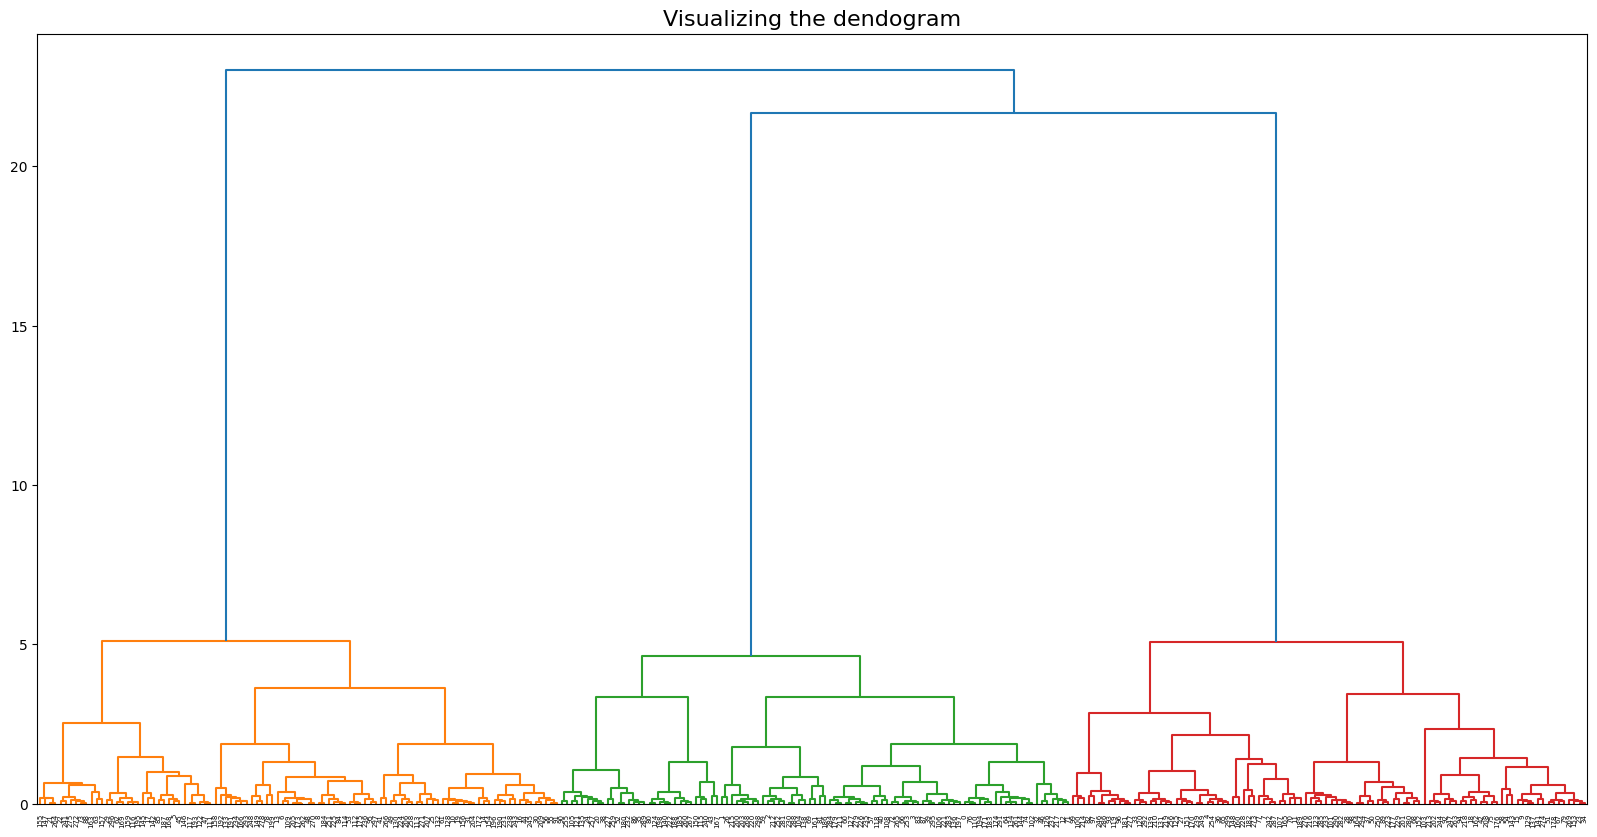

In [56]:
plt.figure(figsize=(20,10))
Dendogram = shc.dendrogram((shc.linkage(X, method='ward')))
plt.title("Visualizing the dendogram", size=16)
plt.show()